In [ ]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
from tqdm import tqdm

import torch
from torch.utils.data import DataLoader
from diffusers import AutoencoderKL, AutoencoderKLFlux2

from models.advanced_deature_encoder import (
    MAEResNet, 
)
from custom_datasets.pokemon_dataset import PokemonDataset
from utils import show_batch_grid, get_number_of_parameters

import os

/home/msst/Utils/miniconda3/envs/qenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DEVICE = "cuda:0"
IMG_SIZE = 128

dataset_path = "/home/msst/repo/drifting/data/CelebA"
dataset_type = "FACES"

pokemon_dataset = PokemonDataset(root_dir=dataset_path, img_size=IMG_SIZE, dataset_type=dataset_type)

Number of images: 202599


In [ ]:
# vae_name = "flux-vae"
# vae =  AutoencoderKLFlux2.from_pretrained(
#     "./checkpoints/flux_vae",
#     device_map="cuda",
#     torch_dtype=torch.bfloat16
# ).eval()
# LATENT_SIZE = IMG_SIZE // 8
# LATENT_CHANNELS = 32


# print("VAE:")
# get_number_of_parameters(vae)
# vae = torch.compile(vae, mode="reduce-overhead")


vae_name = "sd-vae"
vae =  AutoencoderKL.from_pretrained(
    "./checkpoints//sd-vae-ft-mse",
    device_map="cuda",
    torch_dtype=torch.bfloat16
).eval()
LATENT_SIZE = IMG_SIZE // 8
LATENT_CHANNELS = 4

print("VAE:")
get_number_of_parameters(vae)
vae = torch.compile(vae, mode="reduce-overhead")

VAE:
Params: 83.7M


In [ ]:
MASK_RATIO = 0.5

mae_resnet = MAEResNet(
        in_channels = LATENT_CHANNELS,
        base_channels = 384,
        mask_patch_size = 2,
        input_patch_size = 1,
        layers = (3, 4, 6, 3),
    ).to(torch.bfloat16).cuda()

print("mae_resnet:")
print("Encoder:")
get_number_of_parameters(mae_resnet.encoder)
print("Decoder:")
get_number_of_parameters(mae_resnet.decoder)

opt = torch.optim.AdamW(
    mae_resnet.parameters(), 
    lr=2e-4, 
    betas=(0.9, 0.95),
    weight_decay=0.02,
)

mae_resnet = torch.compile(mae_resnet, mode="reduce-overhead")

mae_resnet:
Encoder:
Params: 765M
Decoder:
Params: 200M


In [5]:
batch_size = 128
dataloader = DataLoader(pokemon_dataset, batch_size=batch_size, shuffle=True, num_workers=8)

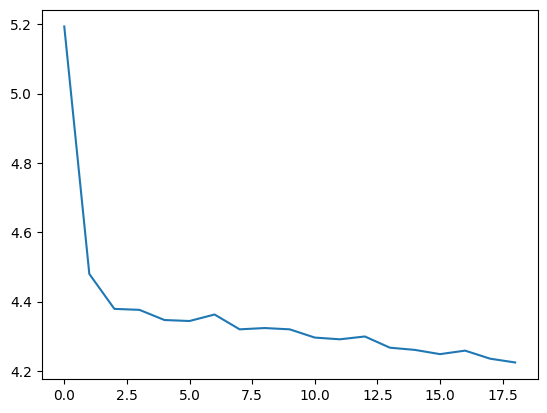

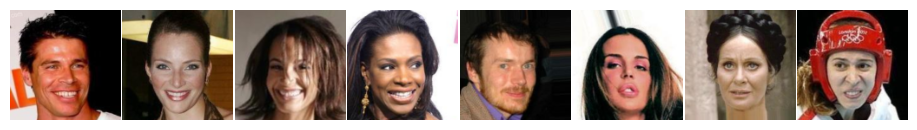

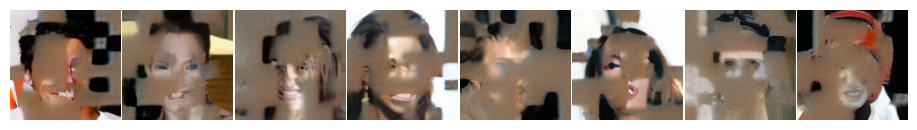

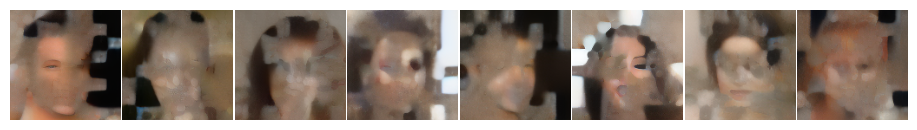

 14%|█▍        | 218/1583 [01:43<15:12,  1.50it/s]

In [ ]:
n_epochs = 100
plot_every = 100
save_step = 2500
save_path = f"/home/msst/repo/drifting/checkpoints/MAE_{vae_name}_{mae_resnet.base_channels}/CelebA"


steps_per_epoch = len(dataloader)

loss_history = []
plot_loss_acc = []
for e in range(n_epochs):
    for step, batch in enumerate(tqdm(dataloader)):
        global_step = e * steps_per_epoch + step + 1
        
        batch = batch.cuda()
        with torch.no_grad():
            batch_latent = vae.encode(batch).latent_dist.sample()


        loss = mae_resnet(batch_latent, mask_ratio=MASK_RATIO)[0]
        loss.backward()
        opt.step()
        opt.zero_grad()
        
        plot_loss_acc.append(loss.item())
        
        
        if (global_step % plot_every == 0) or (global_step == 5):
            loss_history.append(sum(plot_loss_acc) / len(plot_loss_acc))
            plot_loss_acc = []
            clear_output(wait=True)
            plt.plot(loss_history)
            with torch.no_grad():
                test_imgs = next(iter(dataloader))[:8].cuda()
                show_batch_grid(test_imgs, n=8, figsize=(9, 9), denormalize=True)

                test_imgs_latent = vae.encode(test_imgs).latent_dist.sample()
                mask = mae_resnet.make_patch_mask(test_imgs_latent, MASK_RATIO, 2)
                test_imgs_latent_masked = test_imgs_latent * (1.0 - mask)
                test_imgs_masked = vae.decode(test_imgs_latent_masked).sample
                show_batch_grid(test_imgs_masked, n=8, figsize=(9, 9), denormalize=True)

                feats_latent = mae_resnet.encoder(test_imgs_latent_masked)
                recon_latent = mae_resnet.decoder(feats_latent)
                # recon_latent = recon_latent * mask + test_imgs_latent_masked
                recon = vae.decode(recon_latent).sample
                show_batch_grid(recon, n=8, figsize=(9, 9), denormalize=True)
                plt.show()
    
    # if (global_step+1) % save_step == 0:
    os.makedirs(save_path, exist_ok=True)
    torch.save(mae_resnet.state_dict(), f"{save_path}/epochs{e}.pth")
